In [2]:
# Libraries
import os
import numpy as np
import matplotlib.pyplot as plt
from sklearn.utils.class_weight import compute_class_weight
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout, BatchNormalization
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.losses import BinaryCrossentropy
from tensorflow.keras import regularizers

# Paths
processed_path = r"C:\Users\Bushra Shahid\Desktop\IDVS\MRL Model\Data\processed"
train_path     = os.path.join(processed_path, 'train')
test_path      = os.path.join(processed_path, 'test')
model_path     = r"C:\Users\Bushra Shahid\Desktop\IDVS\MRL Model\model"

# Settings
IMG_SIZE    = 64
BATCH_SIZE  = 32
EPOCHS      = 50
NUM_CLASSES = 2
CLASSES     = ['open_eyes', 'closed_eyes']

print("Libraries imported successfully!")
print(f"Train path: {train_path}")
print(f"Test path : {test_path}")

Libraries imported successfully!
Train path: C:\Users\Bushra Shahid\Desktop\IDVS\MRL Model\Data\processed\train
Test path : C:\Users\Bushra Shahid\Desktop\IDVS\MRL Model\Data\processed\test


In [3]:
# Train data generator with augmentation
train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=10,
    width_shift_range=0.1,
    height_shift_range=0.1,
    horizontal_flip=True,
    zoom_range=0.1,
    fill_mode='nearest'
)

# Test data generator (only normalize)
test_datagen = ImageDataGenerator(rescale=1./255)

# Load train data
train_generator = train_datagen.flow_from_directory(
    train_path,
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    color_mode='grayscale',
    class_mode='binary',
    classes=CLASSES,
    shuffle=True
)

# Load test data
test_generator = test_datagen.flow_from_directory(
    test_path,
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    color_mode='grayscale',
    class_mode='binary',
    classes=CLASSES,
    shuffle=False
)

# Compute class weights
class_weights = compute_class_weight(
    class_weight='balanced',
    classes=np.array([0, 1]),
    y=train_generator.classes
)
class_weights = dict(enumerate(class_weights))

print(f"\nClass indices: {train_generator.class_indices}")
print(f"Class weights: {class_weights}")
print(f"\nTrain samples: {train_generator.samples}")
print(f"Test samples : {test_generator.samples}")

Found 8104 images belonging to 2 classes.
Found 2026 images belonging to 2 classes.

Class indices: {'open_eyes': 0, 'closed_eyes': 1}
Class weights: {0: np.float64(1.0), 1: np.float64(1.0)}

Train samples: 8104
Test samples : 2026


In [4]:
# CNN Model for MRL (binary classification)
model = Sequential([
    # Block 1
    Conv2D(32, (3,3), activation='relu', padding='same',
           kernel_regularizer=regularizers.l2(0.001),
           input_shape=(64, 64, 1)),
    BatchNormalization(),
    Conv2D(32, (3,3), activation='relu', padding='same',
           kernel_regularizer=regularizers.l2(0.001)),
    BatchNormalization(),
    MaxPooling2D(2, 2),
    Dropout(0.25),

    # Block 2
    Conv2D(64, (3,3), activation='relu', padding='same',
           kernel_regularizer=regularizers.l2(0.001)),
    BatchNormalization(),
    Conv2D(64, (3,3), activation='relu', padding='same',
           kernel_regularizer=regularizers.l2(0.001)),
    BatchNormalization(),
    MaxPooling2D(2, 2),
    Dropout(0.25),

    # Block 3
    Conv2D(128, (3,3), activation='relu', padding='same',
           kernel_regularizer=regularizers.l2(0.001)),
    BatchNormalization(),
    MaxPooling2D(2, 2),
    Dropout(0.25),

    # Fully connected layers
    Flatten(),
    Dense(128, activation='relu',
          kernel_regularizer=regularizers.l2(0.001)),
    BatchNormalization(),
    Dropout(0.5),

    # Output layer (binary)
    Dense(1, activation='sigmoid')
])

# Compile model
model.compile(
    optimizer=Adam(learning_rate=0.0005),
    loss='binary_crossentropy',
    metrics=['accuracy']
)

model.summary()

c:\Users\Bushra Shahid\Desktop\IDVS\ml_venv\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 64, 64, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 64, 64, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 64, 64, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 64, 64, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 32, 32, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 32, 32, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 32, 32, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 32, 32, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 32, 32, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 32, 32, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 16, 16, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 16, 16, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 16, 16, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 16, 16, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 8, 8, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 8, 8, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 8192)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │     1,048,704 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,189,473 (4.54 MB)

 Trainable params: 1,188,577 (4.53 MB)

 Non-trainable params: 896 (3.50 KB)

In [5]:
# Create model directory if not exists
os.makedirs(model_path, exist_ok=True)

# Callbacks
callbacks = [
    # Stop training if val_loss na sudre 10 epochs tak
    EarlyStopping(
        monitor='val_loss',
        patience=10,
        restore_best_weights=True,
        verbose=1
    ),

    # Learning rate kam karo agar val_loss na sudre 5 epochs tak
    ReduceLROnPlateau(
        monitor='val_loss',
        factor=0.5,
        patience=5,
        min_lr=0.00001,
        verbose=1
    ),

    # Save best model automatically
    ModelCheckpoint(
        filepath=os.path.join(model_path, 'mrl_best_model.keras'),
        monitor='val_accuracy',
        save_best_only=True,
        verbose=1
    )
]

# Train model
history = model.fit(
    train_generator,
    epochs=EPOCHS,
    validation_data=test_generator,
    class_weight=class_weights,
    callbacks=callbacks,
    verbose=1
)

print("\nTraining complete!")

Epoch 1/50
254/254 ━━━━━━━━━━━━━━━━━━━━ 0s 500ms/step - accuracy: 0.9128 - loss: 0.6703
Epoch 1: val_accuracy improved from None to 0.50000, saving model to C:\Users\Bushra Shahid\Desktop\IDVS\MRL Model\model\mrl_best_model.keras

Epoch 1: finished saving model to C:\Users\Bushra Shahid\Desktop\IDVS\MRL Model\model\mrl_best_model.keras
254/254 ━━━━━━━━━━━━━━━━━━━━ 144s 532ms/step - accuracy: 0.9128 - loss: 0.6703 - val_accuracy: 0.5000 - val_loss: 8.6077 - learning_rate: 5.0000e-04
Epoch 2/50
254/254 ━━━━━━━━━━━━━━━━━━━━ 0s 506ms/step - accuracy: 0.9490 - loss: 0.5397
Epoch 2: val_accuracy improved from 0.50000 to 0.63870, saving model to C:\Users\Bushra Shahid\Desktop\IDVS\MRL Model\model\mrl_best_model.keras

Epoch 2: finished saving model to C:\Users\Bushra Shahid\Desktop\IDVS\MRL Model\model\mrl_best_model.keras
254/254 ━━━━━━━━━━━━━━━━━━━━ 136s 534ms/step - accuracy: 0.9490 - loss: 0.5397 - val_accuracy: 0.6387 - val_loss: 2.2709 - learning_rate: 5.0000e-04
Epoch 3/50
254/254 ━━━━

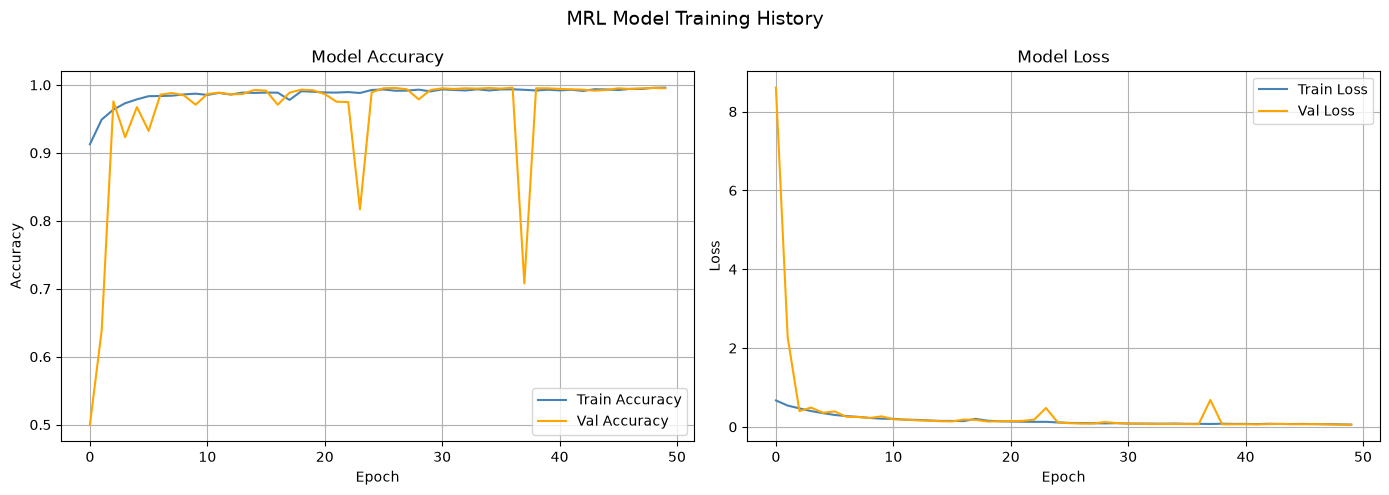

In [6]:
# Plot training history
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Accuracy curve
ax1.plot(history.history['accuracy'], label='Train Accuracy', color='steelblue')
ax1.plot(history.history['val_accuracy'], label='Val Accuracy', color='orange')
ax1.set_title('Model Accuracy')
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Accuracy')
ax1.legend()
ax1.grid(True)

# Loss curve
ax2.plot(history.history['loss'], label='Train Loss', color='steelblue')
ax2.plot(history.history['val_loss'], label='Val Loss', color='orange')
ax2.set_title('Model Loss')
ax2.set_xlabel('Epoch')
ax2.set_ylabel('Loss')
ax2.legend()
ax2.grid(True)

plt.suptitle('MRL Model Training History', fontsize=14)
plt.tight_layout()
plt.show()

64/64 ━━━━━━━━━━━━━━━━━━━━ 6s 88ms/step


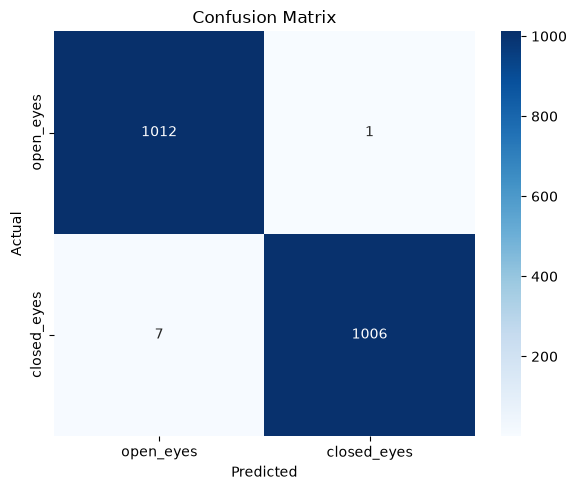


Classification Report:
              precision    recall  f1-score   support

   open_eyes       0.99      1.00      1.00      1013
 closed_eyes       1.00      0.99      1.00      1013

    accuracy                           1.00      2026
   macro avg       1.00      1.00      1.00      2026
weighted avg       1.00      1.00      1.00      2026



In [7]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report
from tensorflow.keras.models import load_model

# Load best saved model
best_model = load_model(r"C:\Users\Bushra Shahid\Desktop\IDVS\MRL Model\model\mrl_best_model.keras")

# Predict on test data
test_generator.reset()
predictions = best_model.predict(test_generator, verbose=1)
predicted_classes = (predictions > 0.5).astype(int).flatten()
true_classes = test_generator.classes

CLASSES = ['open_eyes', 'closed_eyes']

# Confusion matrix
cm = confusion_matrix(true_classes, predicted_classes)

plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=CLASSES, yticklabels=CLASSES)
plt.title('Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.tight_layout()
plt.show()

# Classification report
print("\nClassification Report:")
print(classification_report(true_classes, predicted_classes, target_names=CLASSES))